# Charts for Stock Analysis

## What you'll learn
- How to draw the five basic chart types you will reuse for every stock: line, filled area, return histogram, candlestick, and a styled trend chart.
- Which question each chart answers, and which is the right default for a given job.
- How to plot a price series with plain **matplotlib**, with **seaborn**, and with **mplfinance**.
- The classic ways a chart *misleads* you (hiding the intraday range, linear scale over long horizons, over-smoothing).

A chart is not decoration — it is a compressed answer to one question. Pick the chart that matches the question, then read it honestly.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import mplfinance as mpf

from stocklearn.data import get_history, price_series
from stocklearn.indicators import daily_returns

sns.set_theme(style="whitegrid")

# Change this one line to chart a different company.
ticker = "AAPL"

df = get_history(ticker, period="1y")   # OHLCV + Adj Close, daily bars
close = price_series(df, adjusted=True) # split/dividend-adjusted close
print(df.shape, close.index.min().date(), "->", close.index.max().date())

(251, 8) 2025-10-03 -> 2026-10-02


## 1. Line chart — *"where has the price been?"*

The line chart is the default view of a price series: x = time, y = adjusted close. It answers the
broadest question — **the shape of the price path** — and is the right starting point for any new
ticker.

Use it when you want trend and big moves at a glance. It is a poor tool for comparing two stocks
with different price levels (use a growth-of-$1 chart instead, notebook 02) and it throws away the
open/high/low/volume information entirely — for that you need a candlestick (chart 4).

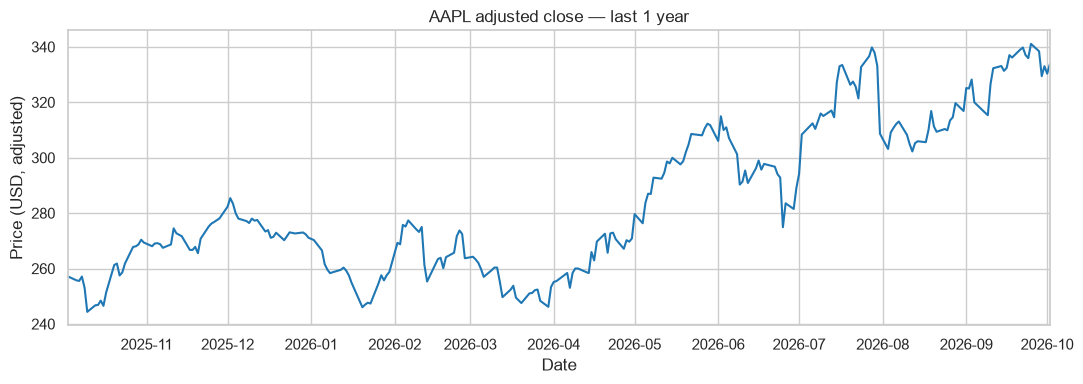

In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(close.index, close.values, color="#1f77b4", linewidth=1.5)
ax.set_title(f"{ticker} adjusted close — last 1 year")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD, adjusted)")
ax.margins(x=0)
plt.tight_layout()
plt.show()

## 2. Filled area chart — *"how much is under the curve?"*

`fill_between` shades the area between the price line and a baseline (here zero). Mechanically it
uses the same data as the line chart, but the solid fill draws the eye to the *level* rather than
crossings, which makes it handy for visual comparisons (e.g. portfolio value, revenue over time).

**When it misleads:** area encodes magnitude as *ink*. Any area chart with a y-axis that does not
start at zero exaggerates differences — a $5 wiggle on a $200 stock fills a huge band. It is only
semi-honest for prices (which are not counts); never use it for volumes or dollar totals without a
zero baseline.

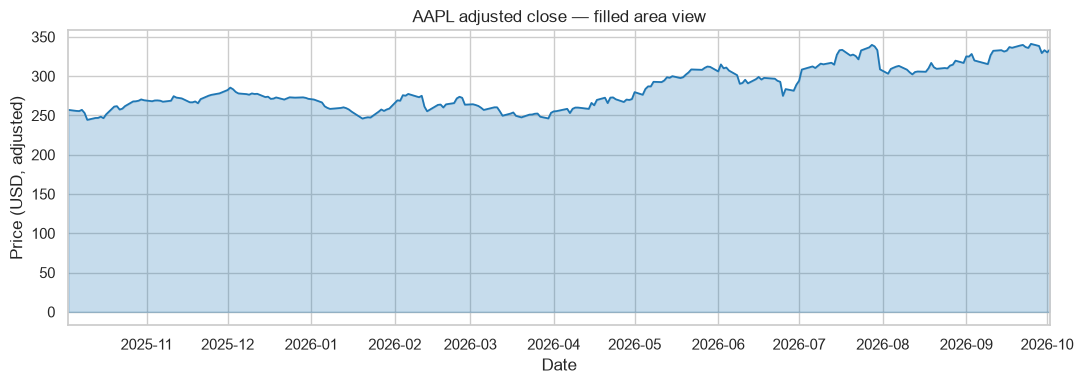

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(close.index, close.values, color="#1f77b4", alpha=0.25)
ax.plot(close.index, close.values, color="#1f77b4", linewidth=1.3)
ax.set_title(f"{ticker} adjusted close — filled area view")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD, adjusted)")
ax.margins(x=0)
plt.tight_layout()
plt.show()

## 3. Histogram of daily returns — *"how volatile is it?"*

Returns are the *changes* in price. A histogram bins them and counts how often each size of daily
move happens. This answers a different question than the price chart: **not "where did it go" but
"how bumpy was the ride"**.

The spread (standard deviation) of this distribution is the daily volatility; notebook 02
annualizes it into the single number `annualized_volatility`. Watch for the **fat tails**: real
return distributions have more extreme days than a perfect bell curve, which is why "it rarely
moves more than 1%" reasoning blows up.

**When it misleads:** a histogram of raw *prices* instead of returns is meaningless — prices drift,
they are not a stationary sample. Always histogram returns, never levels.

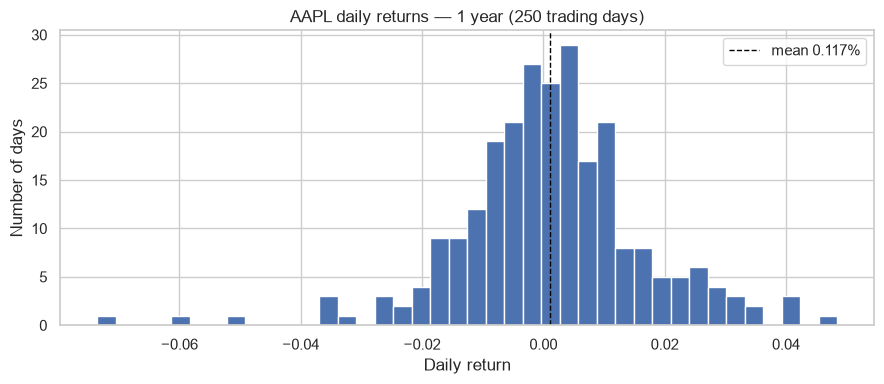

daily std 1.56%  |  worst -7.35%  |  best 4.84%


In [4]:
rets = daily_returns(close).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rets.values, bins=40, color="#4c72b0", edgecolor="white")
ax.axvline(rets.mean(), color="black", linestyle="--", linewidth=1, label=f"mean {rets.mean():.3%}")
ax.set_title(f"{ticker} daily returns — 1 year ({len(rets)} trading days)")
ax.set_xlabel("Daily return")
ax.set_ylabel("Number of days")
ax.legend()
plt.tight_layout()
plt.show()

print(f"daily std {rets.std():.2%}  |  worst {rets.min():.2%}  |  best {rets.max():.2%}")

## 4. Candlestick chart with volume — *"what happened inside each day?"*

A candlestick encodes **four** prices per day (open, high, low, close) plus the day's direction
(green = closed up, red = closed down). Volume trades below in its own panel. This is the trader's
default because it exposes the *intraday range* that a close-only line chart hides.

Read the pieces:
- **body** = open → close (the real move that matters for the daily return);
- **wick/shadow** = the high and low beyond the body — a long upper wick means buyers pushed up but
  sellers won;
- **volume bars** = participation; a breakout on thin volume is suspect.

**When it misleads:** wicks are drawn from intraday extremes, but with `interval="1d"` you do not
see *when* inside the day they occurred, and a candlestick says nothing about volatility-of-
volatility. With hundreds of candles a chart becomes unreadable — zoom to 3–6 months.

`mplfinance` wants the raw OHLCV frame directly, so we pass `df` (not the close Series).

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


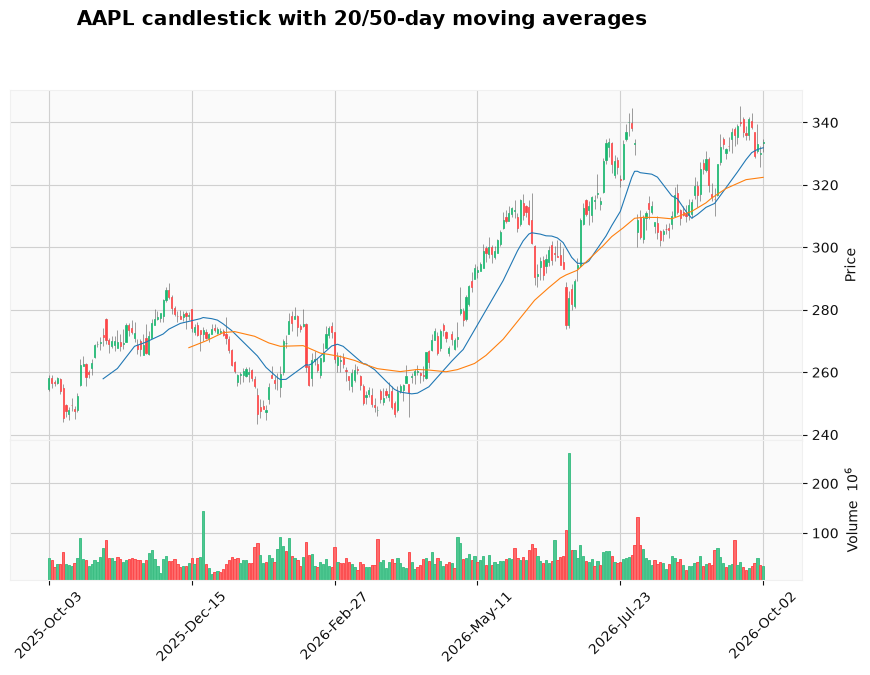

In [5]:
mpf.plot(
    df,
    type="candle",
    volume=True,
    style="yahoo",
    mav=(20, 50),
    title=f"{ticker} candlestick with 20/50-day moving averages",
    figsize=(11, 7),
)

## 5. Seaborn-styled trend chart — *"what is the medium-term trend?"*

Seaborn is a styling and statistics layer on top of matplotlib; `sns.lineplot` adds sensible
defaults (confidence bands for aggregated data, consistent palette). Resampling to **monthly**
closes is a deliberately lossy smoothing step: it removes the daily noise so the trend is obvious.

**When it misleads:** smoothing always buys legibility at the cost of detail. A monthly line hides
a 30% drawdown that recovered within the month, and any averaging can imply smoothness that never
existed. Use the daily line (chart 1) when the question is about *risk*, and the monthly line when
it is about *direction*.

**Log scale note:** for long horizons (5y+) plot `ax.set_yscale("log")`. On a linear axis a 2× gain
looks the same as a $100 gain; compounding makes late-time moves dominate the chart. Log scale
makes *equal percentage moves* equal vertical distances — the honest scale for prices over years.

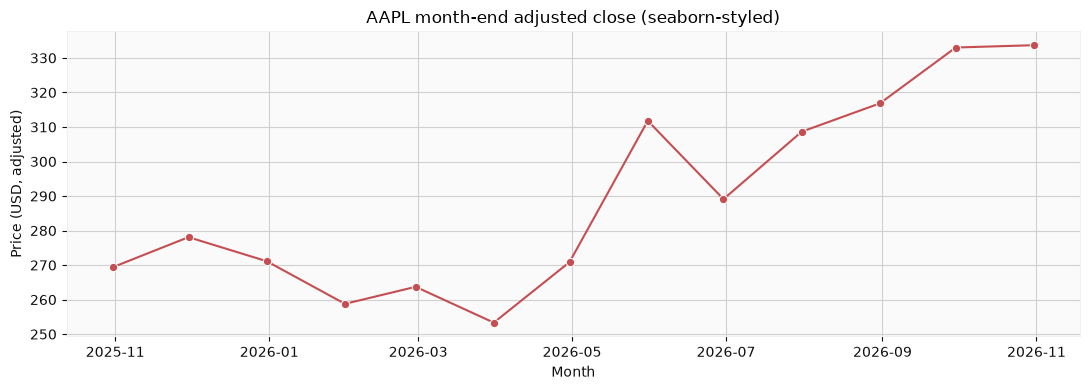

In [6]:
monthly = close.resample("ME").last()   # last close of each calendar month

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(x=monthly.index, y=monthly.values, ax=ax, marker="o", color="#C44E52")
ax.set_title(f"{ticker} month-end adjusted close (seaborn-styled)")
ax.set_xlabel("Month")
ax.set_ylabel("Price (USD, adjusted)")
plt.tight_layout()
plt.show()

## Chart choice cheat-sheet

| Question | Chart | Main pitfall |
|---|---|---|
| Where has the price been? | line (chart 1) | hides OHLC and volume |
| How big is the level / cumulative value? | filled area (chart 2) | ink exaggerates if baseline ≠ 0 |
| How volatile are the daily moves? | return histogram (chart 3) | must use returns, not prices |
| What happened each day, on what volume? | candlestick (chart 4) | unreadable when overcrowded |
| What is the medium-term direction? | smoothed line (chart 5) | smoothing hides risk |
| Long-horizon growth comparison | log-scale line | linear axis distorts compounding |

Two habits that prevent most chart lies: **label the axis and units**, and ask *"what did plotting
this choice throw away?"*

## Recap / try this
- Swap `ticker` in the setup cell to another symbol (e.g. `"MSFT"`, `"TSLA"`) and re-run every cell.
- Change chart 1's `ax.plot(...)` to `ax.set_yscale("log")` and see how a 5-year view would differ.
- Fetch `get_history(ticker, period="6mo", interval="1wk")` and pass it to `mpf.plot` — weekly
  candles trade daily noise for a cleaner trend at the cost of resolution.
- Overlay `price_series(df)` and a 50-day SMA yourself with `from stocklearn.indicators import sma`
  before jumping into notebook 03.